# Linear reconstruction test

Here I included a brief overview of how to read the dataset, and perform basic linear reconstruction with CG-SENSE. 
For notation, I will use:
- nq = number of q samples
- mb = multi-band factor
- ns = number of slice groups (We also refer to slice groups as "slabs")
- nc = number of coil channels
- nx = size of phase encoding dimension
- ny = size of frequency encoding dimension
- nz = number of aquired slices (nz = mb * ns)

The most import fields in the dataset are
- ksp_mb (ns, nq, nc, nx, ny) : The raw kspace / qspace data. It is undersampled at R = 2, and accelerated with multi-band factor (mb) = 5.

- maps (ns, mb, nc, nx, ny) : Coil sensitivity maps from ESPIRIT. These do not have q dimension

- spsg_recon_r2 : (ns, nq, mb, nc, nx, ny) : SPSG reconstruction of the R2 kspace data. This is the "standard" method and can be used as comparison with CG-SENSE

- fov_shifts : This is a list with the FOV shift pattern for the multi-band data. Each entry corresponds to the fraction of the PE FOV that has been shifted for each MB slice



In [ ]:
import os
import h5py
from pathlib import Path
from utils import *
os.environ["CUDA_VISIBLE_DEVICES"] = "3" 

device = "cuda" #"cpu"

subject = 2
resolution = "1pt17"
base_dir = Path("/home/naxos2-raid40/avela019/rafael_data/fMRI_2026/dwi_data")
save_file = base_dir / f"dwi_{resolution}_subj{subject}.h5"

# A dictionary with the indices of the q-space samples corresponding 
# to a speicifc b-value
b_seg = {
0:     list(range(0, 7)),
1500:  list(range(7, 53)),
3000:  list(range(53, 99)),
"all": list(range(99))
}

# I am reading all qspace sample, but just a single slab (slab index 10)
b = "all"
slab_idx = 10
ns = 1

with h5py.File(save_file, 'r') as f:
    #spsg_recon_r2 = f["spsg_recon_r2"][slab_idx : slab_idx + n_slabs, b_seg[b], ...]
    ksp = f["ksp_mb"][slab_idx : slab_idx + ns, b_seg[b], ...]
    maps = f["maps"][slab_idx : slab_idx + ns]
    size = f.attrs["size"]
    fov_shifts = f.attrs["fov_shifts"]

ns, nq, mb, nc, nx, ny  = size
nz = mb * ns

# I don't care about the slab dimension for now, so I'll get rid of it
ksp = ksp[0] 
maps = maps[0]

# Move to torch
ksp = torch.from_numpy(ksp)
maps = torch.from_numpy(maps)

# Create a mask
acceleration_factor = 2
mask = mask_generator(nx, ny, acceleration_factor)
mask = torch.from_numpy(mask)

We now try running CG-SENSE on this slab and plotting the results

In [ ]:
import importlib
import data_consistency as l
importlib.reload(l)
from data_consistency import Data_consistency

with torch.no_grad():
    dc = Data_consistency()
    zerofilled = dc.EH(ksp, maps, mask)
    recon = dc(zerofilled, maps, mask, CG_iter = 5)

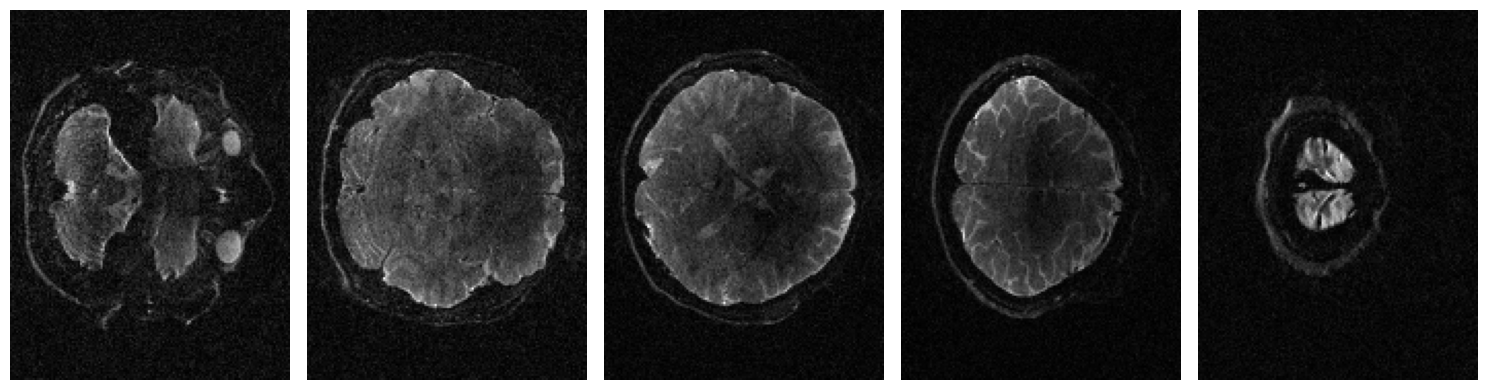

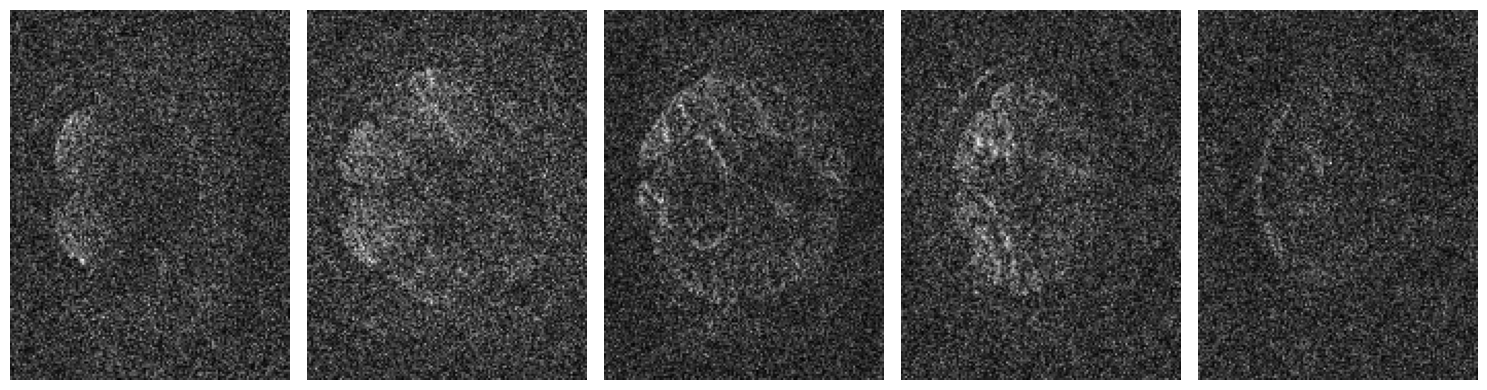

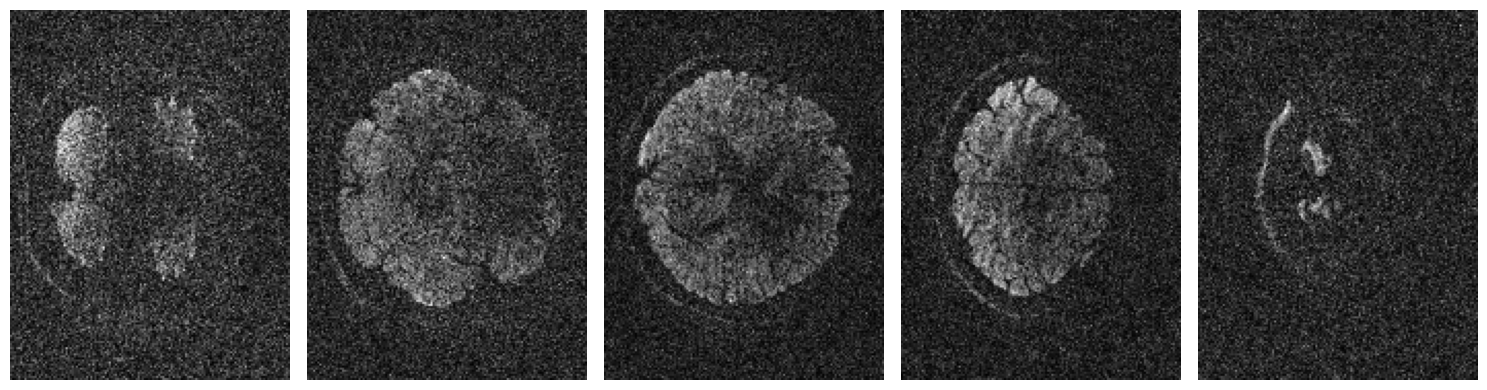

In [ ]:
recon_np = recon.abs().cpu().numpy()
for i in [0, 32, 78]:
    img = shift_fov(recon_np[i], -fov_shifts, xp = np)
    quick_plot(img, gs = (1,5))

mean_b3000 = np.mean(np.abs(recon_np[b_seg[3000]]))
